# Week 2 — 정기 촬영 기능
**환경**: Python 3.10.11 / Windows / VSCode Jupyter

**동작**
- 일정 간격(INTERVAL_SEC)마다 RGB + 뎁스 이미지 자동 저장
- 저장 폴더: `./sleep_frames/YYYYMMDD/`
- Kinect 없으면 웹캠으로 자동 대체

**실행 순서**: 셀을 위에서부터 순서대로 실행하세요 (Shift+Enter)

## 0. 패키지 설치
처음 한 번만 실행하면 됩니다

In [1]:
# 처음 한 번만 실행
# Kinect 사용 시 pykinect-azure도 설치
%pip install matplotlib 


Note: you may need to restart the kernel to use updated packages.


## 1. 라이브러리 로드 & Kinect 연결 확인

In [2]:
import cv2
import numpy as np
import time
import os
from datetime import datetime
from pathlib import Path

# Kinect 연결 시도
try:
    import pykinect_azure as pykinect
    KINECT_AVAILABLE = True
    print("[OK] Kinect 사용 가능")
except ImportError:
    KINECT_AVAILABLE = False
    print("[웹캠 모드] pykinect_azure 없음 → 웹캠으로 대체 실행")

print(f"OpenCV 버전: {cv2.__version__}")
print(f"NumPy 버전: {np.__version__}")

[웹캠 모드] pykinect_azure 없음 → 웹캠으로 대체 실행
OpenCV 버전: 4.13.0
NumPy 버전: 2.2.6


import cv2
import numpy as np
import time
import os
import sys
from datetime import datetime
from pathlib import Path

sys.path.insert(0, "..")     # backend/ → utils 패키지 접근용
sys.path.insert(0, "../..")  # 프로젝트 루트 → config.py 접근용

from utils.db import upload_image

# Kinect 연결 시도
try:
    import pykinect_azure as pykinect
    KINECT_AVAILABLE = True
    print("[OK] Kinect 사용 가능")
except ImportError:
    KINECT_AVAILABLE = False
    print("[웹캠 모드] pykinect_azure 없음 → 웹캠으로 대체 실행")

print(f"OpenCV 버전: {cv2.__version__}")
print(f"NumPy 버전: {np.__version__}")

In [3]:
# =============================================
#  설정값 — 필요 시 여기서 수정
# =============================================

INTERVAL_SEC  = 5        # 촬영 간격 (초) — 테스트: 5 / 실제 수면: 60
SAVE_BASE_DIR = Path("../sleep_frames") # 저장 루트 폴더
SHOW_PREVIEW  = True     # 미리보기 창 표시 여부

# 저장 폴더 생성 (날짜별 구분)
today    = datetime.now().strftime("%Y%m%d")
SAVE_DIR = SAVE_BASE_DIR / today
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"촬영 간격  : {INTERVAL_SEC}초")
print(f"저장 폴더  : {SAVE_DIR.resolve()}")

촬영 간격  : 5초
저장 폴더  : /Users/dandelion/Documents/26-1/HCI_Project_SleepPostureAnalysis/backend/sleep_frames/20260511


## 3. 공통 함수 정의

In [4]:
def save_images(color_image, depth_image) -> tuple:
    """RGB + 뎁스 이미지를 타임스탬프 파일명으로 저장"""
    timestamp   = int(time.time())
    color_path  = SAVE_DIR / f"{timestamp}_regular_color.png"
    depth_path  = SAVE_DIR / f"{timestamp}_regular_depth.png"

    cv2.imwrite(str(color_path), color_image)
    cv2.imwrite(str(depth_path), depth_image)

    return str(color_path), str(depth_path)


def depth_to_colormap(depth_image) -> np.ndarray:
    """뎁스 이미지를 보기 좋게 컬러맵으로 변환"""
    depth_norm = cv2.normalize(
        depth_image, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)
    return cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)


def draw_overlay(image, next_capture_in: float, count: int) -> np.ndarray:
    """미리보기 화면에 촬영 정보 오버레이"""
    overlay = image.copy()
    h, w    = overlay.shape[:2]

    cv2.rectangle(overlay, (0, 0), (w, 55), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.5, image, 0.5, 0, overlay)
    cv2.putText(
        overlay,
        f"다음 촬영까지: {int(next_capture_in)}초  |  저장: {count}장",
        (10, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8, (255, 255, 255), 2
    )
    return overlay


def print_summary(save_count: int):
    """종료 시 저장 결과 요약 출력"""
    files      = sorted(SAVE_DIR.glob("*.png"))
    total_mb   = sum(f.stat().st_size for f in files) / (1024 * 1024)

    print("\n" + "=" * 45)
    print(f" 촬영 종료 — 총 {save_count}장 저장")
    print(f" 저장 위치: {SAVE_DIR.resolve()}")
    print(f" 파일 수: {len(files)}개  |  총 용량: {total_mb:.1f} MB")
    print("=" * 45)
    for f in files[-6:]:
        print(f"  {f.name}  ({f.stat().st_size / 1024:.0f} KB)")


print("[OK] 함수 정의 완료")

[OK] 함수 정의 완료


## 4-A. 정기 촬영 실행 — Kinect 모드
Kinect가 연결된 경우 이 셀을 실행하세요  
종료: 미리보기 창에서 `q` 키

In [5]:
if not KINECT_AVAILABLE:
    print("Kinect 미연결 → 아래 4-B 셀(웹캠 모드)을 실행하세요")
else:
    pykinect.initialize_libraries()

    device_config = pykinect.default_configuration
    device_config.color_resolution = pykinect.K4A_COLOR_RESOLUTION_1080P
    device_config.depth_mode       = pykinect.K4A_DEPTH_MODE_NFOV_UNBINNED
    device = pykinect.start_device(config=device_config)

    print(f"[Kinect] 연결 성공! {INTERVAL_SEC}초마다 자동 촬영 시작")
    print("미리보기 창에서 'q' 키를 누르면 종료됩니다\n")

    last_capture_time = 0
    save_count        = 0

    try:
        while True:
            capture                    = device.update()
            ret_color, color_image     = capture.get_color_image()
            ret_depth, depth_image     = capture.get_depth_image()

            if not ret_color or not ret_depth:
                time.sleep(0.1)
                continue

            now     = time.time()
            next_in = max(0, INTERVAL_SEC - (now - last_capture_time))

            # ── 정기 촬영 ──────────────────────────
            if now - last_capture_time >= INTERVAL_SEC:
                depth_vis              = depth_to_colormap(depth_image)
                color_path, depth_path = save_images(color_image, depth_vis)
                save_count            += 1
                last_capture_time      = now
                print(f"[{datetime.now().strftime('%H:%M:%S')}] "
                      f"촬영 #{save_count} 완료")
                print(f"  → {color_path}")

            # ── 미리보기 ───────────────────────────
            if SHOW_PREVIEW:
                depth_vis = depth_to_colormap(depth_image)
                preview   = draw_overlay(color_image, next_in, save_count)
                cv2.imshow("RGB (q: 종료)",
                           cv2.resize(preview, (1280, 720)))
                cv2.imshow("Depth",
                           cv2.resize(depth_vis, (640, 360)))

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

            time.sleep(0.5)

    except KeyboardInterrupt:
        print("[종료]")
    finally:
        device.close()
        cv2.destroyAllWindows()
        print_summary(save_count)

Kinect 미연결 → 아래 4-B 셀(웹캠 모드)을 실행하세요


## 4-B. 정기 촬영 실행 — 웹캠 모드 (Kinect 없을 때)
Kinect 없이 전체 흐름을 테스트할 때 이 셀을 실행하세요  
종료: 미리보기 창에서 `q` 키

In [8]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("[오류] 웹캠 연결 실패")
else:
    print(f"[웹캠] {INTERVAL_SEC}초마다 자동 촬영 시작")
    print("미리보기 창에서 'q' 키를 누르면 종료됩니다\n")

    last_capture_time = 0
    save_count        = 0

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            now       = time.time()
            next_in   = max(0, INTERVAL_SEC - (now - last_capture_time))
            gray      = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            depth_sim = cv2.applyColorMap(gray, cv2.COLORMAP_JET)

            # ── 정기 촬영 ──────────────────────────
            if now - last_capture_time >= INTERVAL_SEC:
                color_path, depth_path = save_images(frame, depth_sim)
                save_count            += 1
                last_capture_time      = now
                print(f"[{datetime.now().strftime('%H:%M:%S')}] "
                      f"촬영 #{save_count} 완료")
                print(f"  → {color_path}")

            # ── 미리보기 ───────────────────────────
            if SHOW_PREVIEW:
                preview = draw_overlay(frame, next_in, save_count)
                cv2.imshow("웹캠 (q: 종료)", preview)
                cv2.imshow("Depth 시뮬레이션", depth_sim)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    except KeyboardInterrupt:
        print("[종료]")
    finally:
        cap.release()
        cv2.destroyAllWindows()
        print_summary(save_count)

[웹캠] 5초마다 자동 촬영 시작
미리보기 창에서 'q' 키를 누르면 종료됩니다

[11:34:34] 촬영 #1 완료
  → ../sleep_frames/20260511/1778466874_regular_color.png
[11:34:39] 촬영 #2 완료
  → ../sleep_frames/20260511/1778466879_regular_color.png

 촬영 종료 — 총 2장 저장
 저장 위치: /Users/dandelion/Documents/26-1/HCI_Project_SleepPostureAnalysis/backend/sleep_frames/20260511
 파일 수: 4개  |  총 용량: 6.4 MB
  1778466874_regular_color.png  (1835 KB)
  1778466874_regular_depth.png  (1250 KB)
  1778466879_regular_color.png  (2043 KB)
  1778466879_regular_depth.png  (1406 KB)


## 5. 저장된 이미지 확인
촬영 후 저장된 파일을 노트북 안에서 바로 확인합니다

C:\Users\qkrgj\AppData\Local\Temp\ipykernel_29764\428861120.py:25: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qkrgj\AppData\Local\Temp\ipykernel_29764\428861120.py:25: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qkrgj\AppData\Local\Temp\ipykernel_29764\428861120.py:25: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qkrgj\AppData\Local\Temp\ipykernel_29764\428861120.py:25: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qkrgj\AppData\Local\Temp\ipykernel_29764\428861120.py:25: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\qkrgj\AppData\Local\Temp\ipykernel_29764\428861120.py:25: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(

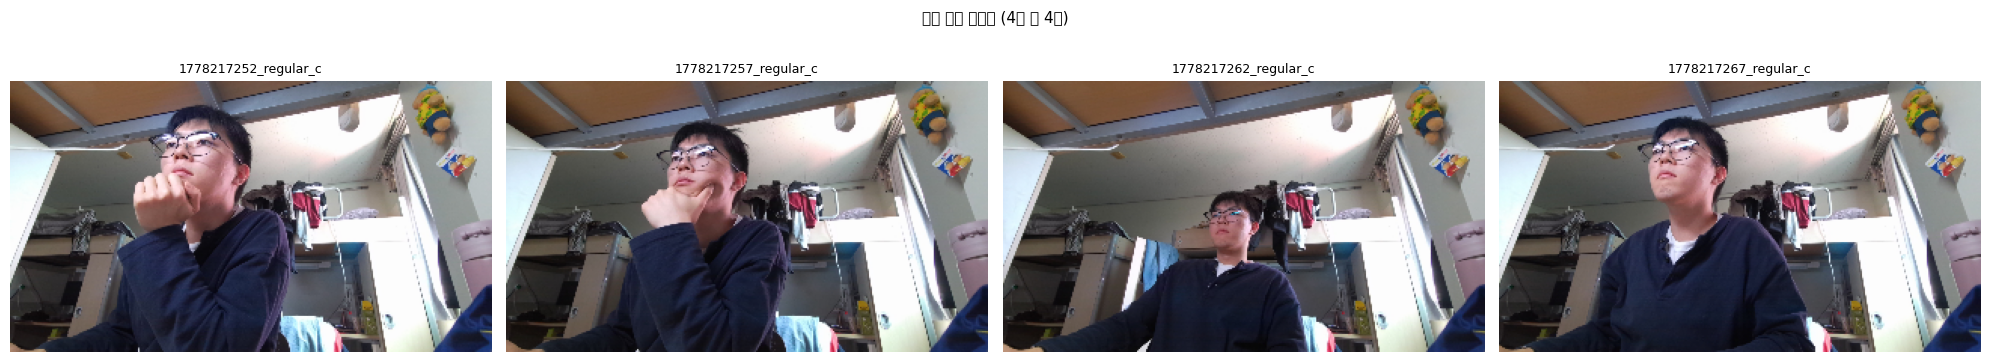

전체 저장 경로: C:\Users\qkrgj\Downloads\sleep_project_v2\sleep_project_v2\backend\notebooks\sleep_frames\20260508


In [16]:
import matplotlib.pyplot as plt

color_files = sorted(SAVE_DIR.glob("*_color.png"))

if not color_files:
    print("저장된 이미지 없음 — 먼저 4-A 또는 4-B 셀을 실행하세요")
else:
    # 최근 저장된 이미지 최대 4장 표시
    show_files = color_files[-4:]
    fig, axes  = plt.subplots(1, len(show_files), figsize=(5 * len(show_files), 4))

    if len(show_files) == 1:
        axes = [axes]

    for ax, f in zip(axes, show_files):
        img = cv2.imread(str(f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (320, 180))
        ax.imshow(img)
        ax.set_title(f.name[:20], fontsize=9)
        ax.axis("off")

    plt.suptitle(f"최근 저장 이미지 ({len(color_files)}장 중 {len(show_files)}장)",
                 fontsize=11)
    plt.tight_layout()
    plt.show()
    print(f"전체 저장 경로: {SAVE_DIR.resolve()}")